# A notebook for plotting main results

These include:
1. Coding of individual behavioral regressors (e.g. feedback, value, target, etc.)
2. Coding of historycal outcomes
3. Distribution of coding (laminare, depth, etc.)
4. Maybe list of units with very strong coding (cherry picked examples)
5. Maybe try to find RPE according to the paper of Kennerley (2011 Double dissociation), or just see how many units do positive or negative coding of reward.

---
# Setup

In [3]:
##% imports
import os

from matplotlib import cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import binomtest

from popy.decoding.population_decoders import *
from popy.plotting.plotting_tools import plot_keypoints
from popy.plotting.plot_cortical_grid import plot_on_cortical_grid_value_fb_custom as plot_on_cortical_grid
from popy.decoding.decoder_tools import mask_N_consecutives

import popy.config as cfg
from popy.config import COLORS

# fontsize is 8
plt.rcParams.update({'font.size': 8})


In [4]:
##% helper functions
def load_res(fname, target=None, add_target_to_fname=True):
    floc = os.path.join(
        cfg.PROJECT_PATH_LOCAL,
        "notebooks",
        "glm",
        "results",
        f"{fname}_target_{target}" if add_target_to_fname else fname,
        "scores.nc",
    )
    print(f"loading {floc}")

    ds = xr.open_dataset(floc, engine="netcdf4")
    ds.close()
    return ds.copy("deep")


def add_lpfc_subregions(ds_fb_value_full):
    
    from popy.io_tools import load_metadata

    # adding subregions: MCC, dLPFC, vLPFC
    metadata = load_metadata()
    subregions = []
    for unit in ds_fb_value_full.unit.values:
        unit_data = ds_fb_value_full.sel(unit=unit)
        monkey = unit_data.monkey.values
        session = unit_data.session.values
        area = unit_data.area.values

        if area == "LPFC":
            lprc_subregion = metadata.loc[
                (metadata["monkey"] == monkey) & 
                (metadata["session"] == session), "LPFC_subregion"].values[0]
            
            subregions.append(lprc_subregion)

        elif area == "MCC":
            subregions.append('MCC')
        else:
            raise ValueError(f"Unknown area: {area}")

    # add subregions to the dataset
    ds_fb_value_full = ds_fb_value_full.assign_coords(
        subregion=("unit", subregions)
    )
    return ds_fb_value_full


def extract_significant_units(ds_fb_value_full, plim=0.05, n_consecutives=2, t_feedback=[0, 1], t_history=[-1, 0]):

    # get significant times and units
    signifs_fb_all = ds_fb_value_full.sel(time=slice(*t_feedback)).CPDs_p_vals_feedback < plim
    signifs_val_all = ds_fb_value_full.sel(time=slice(*t_history)).CPDs_p_vals_stay_value < plim

    signifs_fb = mask_N_consecutives(signifs_fb_all, N=n_consecutives, non_signif_coding='0')  # mask 3 consecutives
    signifs_val = mask_N_consecutives(signifs_val_all, N=n_consecutives, non_signif_coding='0')  # mask 3 consecutives

    # is there ANY time point for a given unit that is significant?
    if_signifs_fb = signifs_fb.sum("time") > 0
    if_signifs_val = signifs_val.sum("time") > 0

    signif_groups = []
    for if_signif_fb, if_signif_value in zip(if_signifs_fb.values, if_signifs_val.values):
        if (not if_signif_fb) and (not if_signif_value):
            signif_groups.append('None')
        elif if_signif_fb and if_signif_value:
            signif_groups.append('Both')
        elif if_signif_fb:
            signif_groups.append('Fb only')
        elif if_signif_value:
            signif_groups.append('Value only')

    # get corresponding tvals
    tvals_fb_all = ds_fb_value_full.sel(time=slice(*t_feedback)).t_vals_feedback
    #tvals_fb_all = tvals_fb_all.where(signifs_fb, np.nan)  # mask non-significant values
    tvals_fb_max = tvals_fb_all.max("time")
    tvals_fb_min = tvals_fb_all.min("time")

    tvals_fb_best = []
    for tval_fb_max, tval_fb_min in zip(tvals_fb_max.values, tvals_fb_min.values):
        if tval_fb_max >= np.abs(tval_fb_min):
            tvals_fb_best.append(tval_fb_max)
        else:
            tvals_fb_best.append(tval_fb_min)

    tvals_val_all = ds_fb_value_full.sel(time=slice(*t_history)).t_vals_stay_value
    #tvals_val_all = tvals_val_all.where(signifs_val, np.nan)
    tvals_val_max = tvals_val_all.max("time")
    tvals_val_min = tvals_val_all.min("time")

    tvals_val_best = []
    for tval_val_max, tval_val_min in zip(tvals_val_max.values, tvals_val_min.values):
        if tval_val_max >= np.abs(tval_val_min):
            tvals_val_best.append(tval_val_max)
        else:
            tvals_val_best.append(tval_val_min)

    df_unit_significances = pd.DataFrame(
        {
            "unit": ds_fb_value_full.unit.values,
            "monkey": ds_fb_value_full.monkey,
            "session": ds_fb_value_full.session,
            "area": ds_fb_value_full.area,
            "subregion": ds_fb_value_full.subregion,
            #"channel": ds_fb_value_full.channel,
            "signif_group": signif_groups,
            "t_vals_feedback": tvals_fb_best,
            "t_vals_value": tvals_val_best,
        }
    )

    # remove 1% outliers from t_vals_feedback and t_vals_stay_value
    outliers_fb = df_unit_significances.t_vals_feedback.abs() > df_unit_significances.t_vals_feedback.abs().quantile(0.99)
    outliers_value = df_unit_significances.t_vals_value.abs() > df_unit_significances.t_vals_value.abs().quantile(0.99)

    df_unit_significances = df_unit_significances[~(outliers_fb | outliers_value)]
    print(f"Number of units removed due to outliers: {(outliers_fb | outliers_value).sum()}")

    # return
    return df_unit_significances


def prop_significants(df, regressor):
    if len(df) == 0:
        return np.nan
    return df[regressor].mean()


def max_abs(x, y):
    if np.abs(x) > np.abs(y):
        return x
    else:
        return y


def extract_number_of_signifs(df_unit_significances):
    prop_units = []
    for (monkey, session, area), sub_df in df_unit_significances.groupby(["monkey", "session", "area"]):
            # get prop signif units for the current session (for given regressors, for given times(?) )
            n_units = len(sub_df)
            n_signif_fb = len(sub_df.loc[(sub_df['signif_group'] == 'Fb only') | (sub_df['signif_group'] == 'Both')])
            n_signif_value = len(sub_df.loc[(sub_df['signif_group'] == 'Value only') | (sub_df['signif_group'] == 'Both')])

            '''tval_fb_max = sub_df.loc[(sub_df['signif_group'] == 'Fb only') | (sub_df['signif_group'] == 'Both')]['t_vals_feedback'].max()
            tval_fb_min = sub_df.loc[(sub_df['signif_group'] == 'Fb only') | (sub_df['signif_group'] == 'Both')]['t_vals_feedback'].min()
            tval_fb_best = max_abs(tval_fb_max, tval_fb_min)

            tval_value_max = sub_df.loc[(sub_df['signif_group'] == 'Value_only only') | (sub_df['signif_group'] == 'Both')]['t_vals_value'].max()
            tval_value_min = sub_df.loc[(sub_df['signif_group'] == 'Value_only only') | (sub_df['signif_group'] == 'Both')]['t_vals_value'].min()
            tval_value_best = max_abs(tval_value_max, tval_value_min)'''

            # save to dict
            prop_units.append(
                {
                    "monkey": monkey,
                    "session": str(session),
                    "area": area,
                    'subregion': sub_df.subregion.values[0],
                    "n_units": n_units,
                    "n_signif_feedback": n_signif_fb,
                    "n_signif_value": n_signif_value,
                }
            )

    return pd.DataFrame(prop_units)


In [41]:
##% plotting functions
def plot_prop_significant_units_full(ds_full_feedback, regressor_of_interest, smooth=False, time_of_interest=None, plim=0.01, title=None): 
    """
    Plot the proportion of significant units for the feedback condition
    """
    cm = 1/2.54  # centimeters in inches
    fig, axs = plt.subplots(4, 2, figsize=(15 * cm, 20 * cm), sharex=True, sharey='row')
    if not title is None:
        plt.suptitle("all units - cpd feedback (vs history)")
    else:
        plt.suptitle(f'Coding of : {regressor_of_interest}')

    colors = COLORS
    styles = ["-", "--", "-.", ":", ":"]

    n_consecutives = 4

    # thing to plot - most important!
    for m, monkey in enumerate(["ka", "po"]):
        for a, area in enumerate(["vLPFC", "dLPFC", "MCC"]):
            # get results of the two models for the current area and monkey
            ds_curr = ds_full_feedback.sel(
                unit=(ds_full_feedback.monkey == monkey) & (ds_full_feedback.subregion == area)
            )

            # Count values greater than 0.05 in each column, ignoring NaNs
            ax = axs[0, m]

            pvals_matrix = ds_curr[f"p_vals_{regressor_of_interest}"] <= plim  # p-values
            pvals_matrix = mask_N_consecutives(pvals_matrix, N=n_consecutives, non_signif_coding='0')

            mean_signif = np.mean(pvals_matrix, axis=0) * 100
            if smooth:
                mean_signif = np.convolve(mean_signif, np.ones(5)/5, mode='same')  # simple moving average

            ax.plot(
                ds_curr.time.values, mean_signif, label=area,
                color=colors[area], linestyle=styles[0], lw=1
            )

            ax.set_ylabel("Percent. significant (statistical)")
            ax.set_title(f"monkey: {monkey.upper()}")

            ax = axs[1, m]
            coeffs_matrix = ds_curr[f"coeffs_{regressor_of_interest}"].data  # p-values
            mean_coeffs = np.mean((coeffs_matrix <= plim), axis=0)
            if smooth:
                mean_coeffs = np.convolve(mean_coeffs, np.ones(5)/5, mode='same')  # simple moving average
            ax.plot(
                ds_curr.time.values, mean_coeffs, label=area,
                color=colors[area], linestyle=styles[0], lw=1
            )

            ax.set_ylabel("Mean GLM coeff")

            # plot mean CPD
            ax = axs[2, m]
            # mean cpd of the significant units
            CPDs_pvals_matrix = ds_curr[f"CPDs_p_vals_{regressor_of_interest}"] <= plim   # p-values
            CPDs_pvals_matrix = mask_N_consecutives(CPDs_pvals_matrix, N=n_consecutives, non_signif_coding='0')

            mean_signif_cpd = np.mean(CPDs_pvals_matrix, axis=0) * 100
            if smooth:
                mean_signif_cpd = np.convolve(mean_signif_cpd, np.ones(5)/5, mode='same')  # simple moving average

            ax.plot(
                ds_curr.time.values, mean_signif_cpd, label=area,
                color=colors[area], linestyle=styles[0], lw=1
            )

            ax.set_ylabel("Percent. significant CPD")

            ax = axs[3, m]
            # mean cpd of the significant units
            CPDs_matrix = ds_curr[f"CPDs_{regressor_of_interest}"].data  # p-values
            mean_cpd = np.nanmean(CPDs_matrix, axis=0)
            if smooth:
                mean_cpd = np.convolve(mean_cpd, np.ones(5)/5, mode='same')
            ax.plot(
                ds_curr.time.values, mean_cpd, label=area,
                color=colors[area], linestyle=styles[0], lw=1
            )

            ax.set_ylabel("CPD (%, mean without std)")


            for ax in axs[:, m]:
                # plot feedback time
                ax.axvline(0, color="black", lw=.7)

                if time_of_interest is not None:
                    ax.set_xlim(time_of_interest)

                # plot settings
                ax.legend(frameon=False)

                ax.set_xlabel("time relative to feedback (s)")
                #ax.set_ylim(0, 0.45)
                ax.grid(alpha=0.3)

                ax.spines["right"].set_visible(False)
                ax.spines["top"].set_visible(False)

    plt.tight_layout()

    return fig, axs


def plot_neuron_counts(ds):
    df = ds.mean('time').to_dataframe().reset_index()

    #df = df.dropna(subset=['coeffs_feedback'])

    df_counts_nonna = df.dropna(subset=['coeffs_feedback']).groupby(['monkey', 'session', 'subregion']).size().reset_index(name='n_neurons')
    df_counts_onlyna = df[df['coeffs_feedback'].isna()].groupby(['monkey', 'session', 'subregion']).size().reset_index(name='n_neurons')


    df_counts = pd.merge(df_counts_nonna, df_counts_onlyna, on=['monkey', 'session', 'subregion'], how='outer', suffixes=('_nonna', '_onlyna'))
    df_counts.fillna(0, inplace=True)
    df_counts['n_neurons_total'] = df_counts['n_neurons_nonna'] + df_counts['n_neurons_onlyna']

    fig, ax = plt.subplots(figsize=(3, 3))

    sns.barplot(
        data=df_counts.groupby(['monkey', 'subregion']).sum().reset_index(),
        x='subregion',
        y='n_neurons_total',
        hue='monkey',
        ax=ax,
        palette=['white', 'white'],
        edgecolor='black',
        width=0.8,
        alpha=0.8,
    )

    sns.barplot(
        data=df_counts.groupby(['monkey', 'subregion']).sum().reset_index(),
        x='subregion',
        y='n_neurons_nonna',
        hue='monkey',
        ax=ax,
        palette=COLORS,
        width=0.8,
        alpha=0.8
    )


    # Get the number of unique monkey values for positioning
    n_monkeys = len(df_counts['monkey'].unique())
    n_subregions = len(df_counts['subregion'].unique())

    # Get positions of the bars
    subregion_positions = {subregion: i for i, subregion in enumerate(df_counts['subregion'].unique())}
    bar_width = 0.6  # Should match width parameter in barplot
    monkey_offset = bar_width / n_monkeys

    # Print the number of neurons in each subregion for each monkey
    for i, monkey in enumerate(df_counts['monkey'].unique()):
        for subregion in df_counts['subregion'].unique():
            # Get data for this combination
            subset = df_counts[(df_counts['monkey'] == monkey) & (df_counts['subregion'] == subregion)]
            
            n_neurons_total = subset['n_neurons_total'].sum()
            n_neurons_nonna = subset['n_neurons_nonna'].sum()
            n_neurons_onlyna = subset['n_neurons_onlyna'].sum()
            
            # Calculate the correct x position
            x_pos = subregion_positions[subregion]
            
            # Adjust x position within the category based on which monkey
            x_pos = x_pos - (bar_width/2) + (i + 0.5) * monkey_offset

            ax.text(
                x=x_pos,
                y=n_neurons_total + 50,  # Slightly above the bar
                s=f'{str(n_neurons_nonna)}\n({str(n_neurons_onlyna)})',
                ha='center',
                va='bottom',
                fontsize=8
            )

            
            print(f'{monkey} - {subregion}: {subset["n_neurons_total"].sum()} units, {len(subset["session"].unique())} sessions, per session: {subset["n_neurons_total"].mean():.0f} ± {subset["n_neurons_total"].std():.0f}')

            
    sns.despine(ax=ax)

    ax.set_ylabel("Number of neurons")
    ax.set_xlabel("Subregion")
    plt.tight_layout()


    print(f'N units all: {len(df)}, nonna: {df_counts["n_neurons_nonna"].sum()}, onlyna: {df_counts["n_neurons_onlyna"].sum()}')
    print(f'N units all: {len(df)}, nonna: {df_counts["n_neurons_nonna"].sum()}, onlyna: {df_counts["n_neurons_onlyna"].sum()}')


def plot_coeffs_vs_feedback_value(df_unit_significances, paper_format=False):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from matplotlib.gridspec import GridSpec

    # Set font size globally
    plt.rcParams.update({'font.size': 8})

    # Calculate figure dimensions
    total_width = 7.7 * .8  # inches
    n_subplots = len(df_unit_significances.groupby("subregion"))
    height = 2.5 * .8  # adjust as needed

    if paper_format:
        figsize = (total_width, height)
        s = 6  # smaller points for compact subplots
    else:
        figsize = (total_width * 3, height * 3)  # scale up for non-paper
        s = 30

    palette = {
        'None': 'grey',
        'Both': 'tab:blue',
        'Fb only': 'tab:green',
        'Value only': 'tab:orange'
    }

    # Create figure with custom gridspec for jointplot-like layout
    fig = plt.figure(figsize=figsize)

    # Calculate grid dimensions: each subplot needs 3x3 grid (main plot + marginals)
    grid_cols = n_subplots * 3
    gs = GridSpec(3, grid_cols, figure=fig, 
                height_ratios=[.5, 3, 0.2], width_ratios=[3, .5, 0.5] * n_subplots,
                hspace=0.05, wspace=0.05)


    for i, (area, sub_df) in enumerate(df_unit_significances.groupby("subregion")):
        # Calculate grid positions for this subplot
        col_start = i * 3
        
        # Main scatter plot
        ax_main = fig.add_subplot(gs[1, col_start])
        
        # Top marginal (x-axis histogram)
        ax_top = fig.add_subplot(gs[0, col_start], sharex=ax_main)
        
        # Right marginal (y-axis histogram)
        ax_right = fig.add_subplot(gs[1, col_start + 1], sharey=ax_main)
        
        # Create scatter plot for each significance group
        for group, group_df in sub_df.groupby("signif_group"):
            color = palette[group]
            
            # Main scatter plot
            group_df_undersampled = group_df.sample(n=min(len(group_df), 10000), random_state=42)  # downsample to max 1000 points
            ax_main.scatter(group_df_undersampled["t_vals_feedback"], group_df_undersampled["t_vals_value"],
                        c=color, s=s, alpha=0.4, 
                        edgecolors='none', linewidth=0.3, label=group)
        
        # Top marginal histogram (x-values)
        tvals_fb = sub_df.loc[(sub_df["signif_group"] == "Both") | (sub_df["signif_group"] == "Fb only"), "t_vals_feedback"]
        ax_top.hist(tvals_fb, bins=50, alpha=0.5, color='grey', histtype='stepfilled')
        
        # print statistical test: num positive and negative values are same or different?
        pos_count = (tvals_fb > 0).sum()
        neg_count = (tvals_fb < 0).sum()
        total_count = pos_count + neg_count
        print(f"{area} - {group}: pos: {pos_count}, neg: {neg_count} -> proportion of negatives: {neg_count / total_count:.2f}")
        p_value = binomtest(pos_count, total_count, p=0.5, alternative='two-sided')
        print(f"Binomial test for {area} - {group}: p-value = {p_value.pvalue:.4f}")
        
        # Right marginal histogram (y-values)
        tvals_value = sub_df.loc[(sub_df["signif_group"] == "Both") | (sub_df["signif_group"] == "Value only"), "t_vals_value"]
        ax_right.hist(tvals_value, bins=50, alpha=0.5, color='grey', histtype='stepfilled',orientation='horizontal')

        # print statistical test: num positive and negative values are same or different?
        pos_count = (tvals_value > 0).sum()
        neg_count = (tvals_value < 0).sum()
        total_count = pos_count + neg_count
        print(f"{area} - {group}: pos: {pos_count}, neg: {neg_count} -> proportion of negatives: {neg_count / total_count:.2f}")
        p_value = binomtest(pos_count, total_count, p=0.5, alternative='two-sided')
        print(f"Binomial test for {area} - {group}: p-value = {p_value.pvalue:.4f}")

        # Plot reference lines on main plot
        ax_main.axhline(0, color='black', lw=.5, alpha=0.5)
        ax_main.axvline(0, color='black', lw=.5, alpha=0.5)
        
        # Set limits
        ax_main.set_ylim(-9, 9)
        ax_main.set_xlim(-19, 19)
        
        # Set labels (only on leftmost subplot for y-axis)
        ax_main.set_xlabel("Feedback t-values\n(Coefficients / std)", fontsize=8)
        if i == 0:
            ax_main.set_ylabel("Value t-values\n(Coefficients / std)", fontsize=8)
        
        # Set title on top marginal
        ax_top.set_title(f"{area}", fontsize=8, pad=5)
        
        # Set tick parameters
        ax_main.tick_params(labelsize=7)

        ax_main.spines['right'].set_visible(False)
        ax_main.spines['top'].set_visible(False)

        ax_top.spines['bottom'].set_visible(False)
        ax_right.spines['left'].set_visible(False)
        
        # Hide tick labels on marginal plots
        ax_top.tick_params(labelbottom=False, labelsize=6)
        ax_right.tick_params(labelleft=False, labelsize=6)

        ax_top.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax_right.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
        
        # Remove axes spines on marginals
        ax_top.spines['top'].set_visible(False)
        ax_top.spines['right'].set_visible(False)
        ax_right.spines['top'].set_visible(False)
        ax_right.spines['right'].set_visible(False)
        
        # Add legend only to the last subplot
        if i == n_subplots - 1:
            ax_main.legend(fontsize=6, loc='upper right', frameon=True, 
                        fancybox=True, shadow=True, framealpha=0.9)

    # Adjust layout
    plt.tight_layout()

    # Optional: save with high DPI for paper
    # plt.savefig('your_plot.pdf', dpi=300, bbox_inches='tight')
    return fig


def plot_neuron_comparison(df, save_path=None, paperformat=False):
    """
    Create a compact figure comparing neuron distributions between two monkeys for MCC area.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing 'unit', 'monkey', 'area', 'feedback', and 'history' columns
    save_path : str, optional
        Path to save the figure
    """

    if paperformat:
        # fontsize is 8
        plt.rcParams.update({'font.size': 7})

        # Convert cm to inches (6cm × 6cm)
        figsize = (4.5, 5)  # 6cm i
    else:
        # Convert cm to inches (6cm × 6cm)
        figsize = (8, 3)
    
    # Create figure
    fig, axs = plt.subplots(1, 3, figsize=figsize, sharey=True)
    # no gap between subplots
    fig.subplots_adjust(wspace=0)
    
    
    # Categories and positions for bars
    palette = {
        'Fb only': 'tab:green', 
        'Value only': 'tab:orange', 
        'Both': 'tab:blue', 
        'None': 'white'}
    
    # Process each monkey's data
    monkeys = ['ka', 'po']
        
    for a, ax in enumerate(axs):
        area = ['MCC', 'dLPFC', 'vLPFC'][a]
        #for i, monkey in enumerate(monkeys):
            # Filter data for current monkey and MCC area
        monkey_data = df[(df['subregion'] == area)]

        # Calculate counts
        labels = palette.keys()
        values = []
        for label in labels:
            values.append(len(monkey_data[monkey_data['signif_group'] == label]))
        
        # Plot bars
        #offset = width * (i - 0.5)
        wedges, texts, autotexts = ax.pie(
                                  values, 
                                  labels=None,  # assuming x contains your category labels
                                  counterclock=False,  # clockwise direction
                                  colors=palette.values(),
                                  autopct='%1.1f%%',  # show percentages
                                  startangle=90,  # start from top
                                  wedgeprops={'edgecolor': 'black', 'alpha': 0.7})

        # Add value labels (counts) to each wedge
        '''for i, (wedge, value) in enumerate(zip(wedges, values)):
            angle = (wedge.theta2 + wedge.theta1) / 2  # middle angle of wedge
            x_pos = wedge.r * 0.7 * np.cos(np.radians(angle))  # position inside wedge
            y_pos = wedge.r * 0.7 * np.sin(np.radians(angle))
            
            ax.text(x_pos, y_pos, f'{value}', 
                    ha='center', va='center',
                    fontsize=8, fontweight='bold',
                    color='white')  # white text for better contrast
            '''
        '''bars = ax.bar(x, percentages, width, 
                    color=colors,
                    edgecolor='black',
                    #pattern: filled for monkey 'ka' and dotted for monkey 'po'
                    #hatch='\\' if monkey == 'po' else '.',
                    alpha=0.7)
        
        # Add value labels on bars (only counts)
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{value}',
                ha='center', va='bottom',
                fontsize=6)'''
        
        # Customize plot
        '''ax.set_ylabel('% of neurons')
        ax.set_xticks(x)
        ax.set_xticklabels(categories, fontsize=8, rotation=90)'''
        
        # Add legend - filled grey bar for monkey 'ka' and dashed grey bar for monkey 'po'
        if a == 2:  
            ax.legend(fontsize=8, loc='upper left', frameon=False)

        # Add title
        ax.set_title(f'{area}', fontsize=8)
        
        # Remove top and right spines
        '''ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)'''
    
    # Adjust layout
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
    return fig


'''def plot_prop_significant_units(ds_full_feedback, regressor_of_interest, time_of_interest=None, plim=0.01, title=None):  # TODO: USED?
    """
    Plot the proportion of significant units for the feedback condition
    """
    cm = 1/2.54  # centimeters in inches
    fig, axs = plt.subplots(2, 2, figsize=(15 * cm, 10 * cm), sharex=True, sharey='row')
    if not title is None:
        plt.suptitle("all units - cpd feedback (vs history)")

    colors = COLORS
    styles = ["-", "--", "-.", ":", ":"]

    # thing to plot - most important!
    for m, monkey in enumerate(["ka", "po"]):
        for a, area in enumerate(["dLPFC", "vLPFC", "MCC"]):
            # get results of the two models for the current area and monkey
            ds_curr = ds_full_feedback.sel(
                unit=(ds_full_feedback.monkey == monkey) & (ds_full_feedback.subregion == area)
            )

            # cpd_matrix = ds_curr[f"coeffs_{regressor_of_interest}"].values  # pdf scores
            pvals_matrix = ds_curr[f"p_vals_{regressor_of_interest}"].data  # p-values
            CPDs_matrix = ds_curr[f"coeffs_{regressor_of_interest}"].data  # p-values
            # set non-significatn values to nan
            #CPDs_matrix[pvals_matrix > 0.05] = np.nan
            
            # Count values greater than 0.05 in each column, ignoring NaNs
            ax = axs[0, m]
            mean_signif = np.mean((pvals_matrix <= plim), axis=0)  
            ax.plot(
                ds_curr.time.values, mean_signif * 100, label=area,
                color=colors[area], linestyle=styles[0], lw=1
            )

            ax.set_ylabel("Percent. significant units")
            ax.set_title(f"monkey: {monkey.upper()}\ncoding: {regressor_of_interest}")

            # plot mean CPD
            ax = axs[1, m]
            # mean cpd of the significant units
            CPDs_matrix[pvals_matrix > plim] = np.nan
            mean_cpd = np.nanmean(CPDs_matrix, axis=0)
            ax.plot(
                ds_curr.time.values, mean_cpd * 100, label=area,
                color=colors[area], linestyle=styles[0], lw=1
            )

            ax.set_ylabel("Mean GLM coeff OR \nCPD (%, mean without std)")


            for ax in axs[:, m]:
                # plot feedback time
                ax.axvline(0, color="black", lw=.7)

                if time_of_interest is not None:
                    ax.aet_xlim(time_of_interest)

                # plot settings
                ax.legend(frameon=False)

                ax.set_xlabel("time relative to feedback (s)")
                #ax.set_ylim(0, 0.45)
                ax.grid(alpha=0.3)

                ax.spines["right"].set_visible(False)
                ax.spines["top"].set_visible(False)

                
                
    plt.tight_layout()

    return fig, axs


def plot_prop_significant_units_on_surface(ds_full_feedback, regressor_of_interest, time_of_interest=None, plim=0.01, title=None):# TODO: USED?
    """
    Plot the proportion of significant units for the feedback condition
    """

    cm = 1/2.54  # centimeters in inches
    fig, axs = plt.subplots(1, 2, figsize=(10 * cm, 5 * cm), sharex=True, sharey=True)
    if not title is None:
        plt.suptitle("all units - cpd feedback (vs history)")

    colors = COLORS
    styles = ["-", "--", "-.", ":", ":"]

    # thing to plot - most important!
    for m, monkey in enumerate(["ka", "po"]):
        for a, area in enumerate(["LPFC", "MCC"]):
            ax = axs[m]

            # get results of the two models for the current area and monkey
            ds_curr = ds_full_feedback.sel(
                unit=(ds_full_feedback.monkey == monkey) & (ds_full_feedback.area == area)
            )

            if time_of_interest is not None:
                ds_curr = ds_curr.sel(time=slice(*time_of_interest))

            #cpd_matrix = ds_curr[f"coeffs_{regressor_of_interest}"].values  # pdf scores
            pvals_matrix = ds_curr[f"p_vals_{regressor_of_interest}"]  # p-values
            # remove nan values (remove all 'time' of a 'unit' if there is a nan in the p-values)
            pvals_matrix = pvals_matrix.dropna(dim="unit", how='any')

            # set non-significant values to nan
            #cpd_matrix[pvals_matrix > 0.05] = np.nan
            #mask = np.isnan(cpd_matrix)  # create a mask of nan values (including the non-significant ones and the nans in the original data)

            # Count values greater than 0.05 in each column, ignoring NaNs
            mean_signif = np.mean((pvals_matrix <= plim), axis=0)
            ax.plot(
                ds_curr.time.values, mean_signif, label=area,
                color=colors[area], linestyle=styles[0], lw=1
            )

            # plot feedback time
            ax.axvline(0, color="black", lw=.7)

            # plot settings
            ax.legend(frameon=False)

            ax.set_xlabel("time relative to feedback (s)")
            ax.set_ylabel("prop. of significant units")
            #ax.set_ylim(0, 0.45)
            ax.grid(alpha=0.3)

            ax.spines["right"].set_visible(False)
            ax.spines["top"].set_visible(False)

            # set title and labels
            ax.set_title(f"monkey: {monkey.upper()}\ncoding: {regressor_of_interest}")
                
    plt.tight_layout()

    return fig, axs


def plot_summary_statistic(# TODO: USED?
    dss_original,
    plotting_func,
    title=None,
    p_lim=0.05,
    theme=None,
    n_extra_trials=(-1, 0),
):
    dss = [ds.copy() for ds in dss_original]

    fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
    if not title is None:
        plt.suptitle(title)

    # colors = {'LPFC': 'tab:blue', 'MCC': 'grey'}
    # iterable tab colorsú
    if theme is None:
        colors = cm.get_cmap("tab10").colors
    elif theme == 1:
        colors = {"LPFC": "tab:blue", "MCC": "grey"}
        styles = ["-", "--", "-.", ":", ":"]
        styles = {ds.attrs["model_name"]: styles[i] for i, ds in enumerate(dss)}

    for m, monkey in enumerate(["ka", "po"]):
        for a, area in enumerate(["LPFC", "MCC"]):
            ax = axs[m, a]

            # get results of the two models for the current area and monkey
            for i_ds, ds in enumerate(dss):
                ds_curr = ds.sel(unit=(ds.monkey == monkey) & (ds.area == area))
                ax.plot(
                    ds.time.values,
                    plotting_func(ds_curr, p_lim=p_lim),
                    color=colors[area] if theme == 1 else colors[i_ds],
                    linestyle=styles[ds.attrs["model_name"]] if theme == 1 else "-",
                    lw=1,
                    label=f'{ds.attrs["model_name"]}, N={(~np.isnan(ds_curr["scores"])).sum("unit")[0].values}',
                )  # , linestyle=styles[ds.attrs["model_name"]])

            # legend below plot
            ax.legend(loc="upper right")

            # plot key points
            plot_keypoints(
                ax, n_extra_trials=n_extra_trials, fontsize=8, xlabels="both"
            )
            ax.grid(alpha=0.3)

            # set title and labels
            ax.set_title(f"monkey: {monkey}, area: {area}")
            ax.set_ylabel(f"prop. of significant units")
            ax.set_xlabel("time (s)")
            # hide spines
            ax.spines["right"].set_visible(False)
            ax.spines["top"].set_visible(False)

    plt.tight_layout()

    return fig, axs


def prop_significants(ds, p_lim=0.05):# TODO: USED?
    n_non_nan_units = (~np.isnan(ds["scores"])).sum("unit")
    n_significant_units = (ds["p_vals"] <= p_lim).sum("unit")
    return n_significant_units / n_non_nan_units
    # return np.nanmean(ds['p_vals'] <= p_lim, axis=0)

def plot_neuron_comparison_2(df, save_path=None):# TODO: USED?
    """
    Create a compact figure comparing neuron distributions between two monkeys for MCC area.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing 'unit', 'monkey', 'area', 'feedback', and 'history' columns
    save_path : str, optional
        Path to save the figure
    """
    # Convert cm to inches (6cm × 6cm)
    cm_to_inch = 1/2.54
    figsize = (2*5*cm_to_inch, 5*cm_to_inch)  # 6cm i
    
    # Create figure
    fig, axs = plt.subplots(1, 2, figsize=figsize)
    
    # Categories and positions for bars
    channels = df['channel'].unique()
    x = np.arange(len(channels))
    width = 0.35  # Width of bars
    
    # Process each monkey's data
    monkeys = ['ka', 'po']
        
    for a, ax in enumerate(axs):
        area = ['MCC', 'LPFC'][a]
        for i, monkey in enumerate(monkeys):
            # Filter data for current monkey and MCC area
            monkey_data = df[(df['monkey'] == monkey) & (df['area'] == area)]
            
            # Calculate percentages
            percentages = [len(subdf[subdf['signif_valueŰ']])/len(subdf) for channel, subdf in monkey_data.groupby(['channel'])]
            
            # Plot bars
            offset = width * (i - 0.5)
            bars = ax.bar(x + offset, percentages, width, 
                        label=f'Monkey {monkey.upper()}',
                        color=COLORS[monkey],
                        alpha=0.9)        
        
        # Customize plot
        ax.set_ylabel('% of neurons')
        ax.set_xticks(x)
        ax.set_xticklabels(channels, fontsize=4)
        
        # Add legend
        ax.legend(fontsize=8, loc='upper right', frameon=False)

        # Add title
        ax.set_title(f'{area} Neurons', fontsize=8)
        
        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
    return fig
'''


'def plot_prop_significant_units(ds_full_feedback, regressor_of_interest, time_of_interest=None, plim=0.01, title=None):  # TODO: USED?\n    """\n    Plot the proportion of significant units for the feedback condition\n    """\n    cm = 1/2.54  # centimeters in inches\n    fig, axs = plt.subplots(2, 2, figsize=(15 * cm, 10 * cm), sharex=True, sharey=\'row\')\n    if not title is None:\n        plt.suptitle("all units - cpd feedback (vs history)")\n\n    colors = COLORS\n    styles = ["-", "--", "-.", ":", ":"]\n\n    # thing to plot - most important!\n    for m, monkey in enumerate(["ka", "po"]):\n        for a, area in enumerate(["dLPFC", "vLPFC", "MCC"]):\n            # get results of the two models for the current area and monkey\n            ds_curr = ds_full_feedback.sel(\n                unit=(ds_full_feedback.monkey == monkey) & (ds_full_feedback.subregion == area)\n            )\n\n            # cpd_matrix = ds_curr[f"coeffs_{regressor_of_interest}"].values  # pdf scores\n     


# Feedback vs. value CPD

Here we have a GLM model of:

$$
\text{SpikeCount} \sim \text{Feedback} +Value
$$

that we fit in around the feedback event (form -2 to +3 seconds). 

We compute the CPD for the regressors ***Feeback, Values***, with a p-value derived from permutation test of the CPD values.


### Load data

In [34]:
# load data - 1-1 xarray datasets for all the conditions
ds_fb_value_full = load_res("fb_stayvalue_cpd", add_target_to_fname=False)
ds_fb_value_full = add_lpfc_subregions(ds_fb_value_full)    
ds_fb_value_full

loading /Users/zsombi/ZSOMBI/SBRI/PoPy/notebooks/glm/results/fb_stayvalue_cpd/scores.nc


<xarray.Dataset>
Dimensions:                 (unit: 5088, time: 120)
Coordinates:
  * unit                    (unit) object 'ka_230720_LPFC_05_01' ... 'po_2007...
  * time                    (time) float64 -3.0 -2.95 -2.9 ... 2.85 2.9 2.95
    monkey                  (unit) object ...
    session                 (unit) object ...
    area                    (unit) object ...
    channel                 (unit) object ...
    subregion               (unit) <U5 'dLPFC' 'dLPFC' 'dLPFC' ... 'MCC' 'MCC'
Data variables: (12/14)
    scores                  (unit, time) float64 ...
    coeffs_intercept        (unit, time) float64 ...
    t_vals_intercept        (unit, time) float64 ...
    p_vals_intercept        (unit, time) float64 ...
    coeffs_feedback         (unit, time) float64 ...
    t_vals_feedback         (unit, time) float64 ...
    ...                      ...
    t_vals_stay_value       (unit, time) float64 ...
    p_vals_stay_value       (unit, time) float64 ...
    CPDs_feedback           (unit, time) float64 ...
    CPDs_p_vals_feedback    (unit, time) float64 ...
    CPDs_stay_value         (unit, time) float64 ...
    CPDs_p_vals_stay_value  (unit, time) float64 ...
Attributes:
    step_time:         0.05
    n_permutations:    500
    area:              None
    glm_predictors:    ['feedback', 'stay_value']
    cpd_targets:       ['feedback', 'stay_value']
    model:             glm_cpd
    neural_data_type:  spike_counts
    value_type:        continuous
    floc:              /Users/zsombi/ZSOMBI/SBRI/PoPy/notebooks/glm/results/f...
    msg:               Fitting a GLM with feedback only, it is for matteo to ...

ka - MCC: 1487.0 units, 60 sessions, per session: 25 ± 8
ka - vLPFC: 246.0 units, 12 sessions, per session: 20 ± 8
ka - dLPFC: 982.0 units, 48 sessions, per session: 20 ± 9
po - MCC: 1409.0 units, 54 sessions, per session: 26 ± 9
po - vLPFC: 142.0 units, 7 sessions, per session: 20 ± 10
po - dLPFC: 822.0 units, 47 sessions, per session: 17 ± 9
N units all: 5088, nonna: 4911.0, onlyna: 177.0
N units all: 5088, nonna: 4911.0, onlyna: 177.0


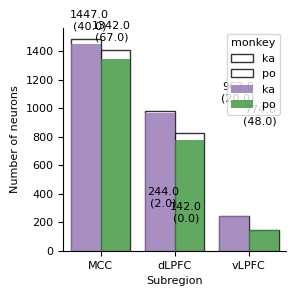

In [42]:
plot_neuron_counts(ds_fb_value_full)

In [26]:
60*12.4

744.0

ka - MCC: 1436.0 neurons total, 60 sessions -> 23.9 neurons per session
ka - dLPFC: 955.0 neurons total, 48 sessions -> 19.9 neurons per session
ka - vLPFC: 242.0 neurons total, 12 sessions -> 20.2 neurons per session
po - MCC: 1318.0 neurons total, 53 sessions -> 24.9 neurons per session
po - dLPFC: 767.0 neurons total, 46 sessions -> 16.7 neurons per session
po - vLPFC: 140.0 neurons total, 7 sessions -> 20.0 neurons per session
N units all: 4858, nonna: 4858, onlyna: 0.0
N units all: 4858, nonna: 4858, onlyna: 0.0


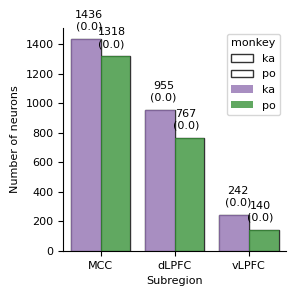

In [8]:
# remove nan values from the dataset
ds_fb_value_full = ds_fb_value_full.dropna(dim="unit", how='any')
ds_fb_value_full
plot_neuron_counts(ds_fb_value_full)

### Show time evolution

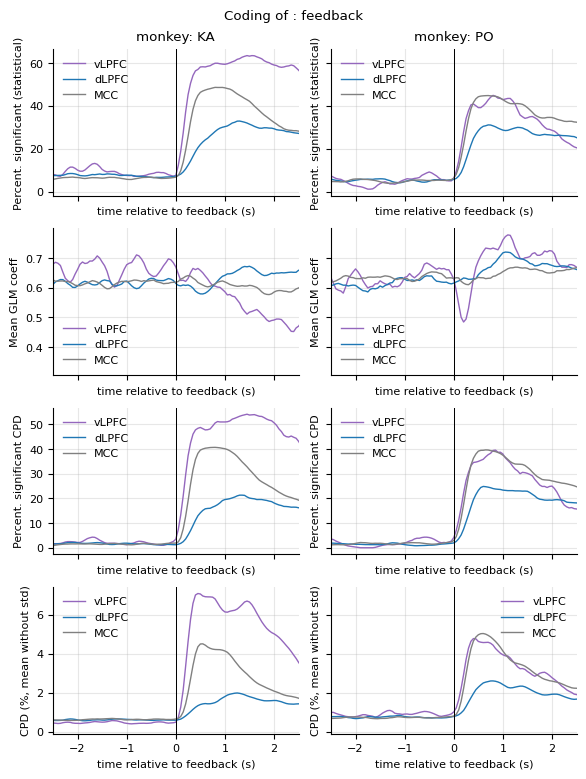

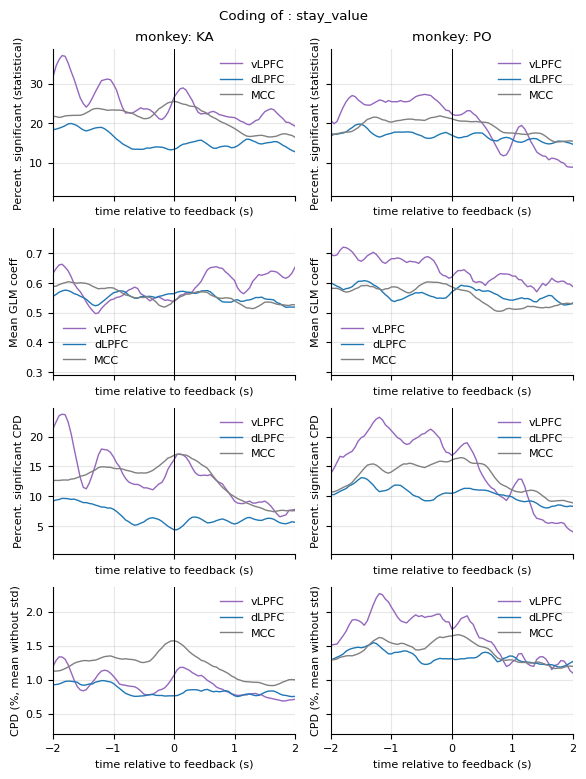

In [9]:
regressor_of_interest = "feedback"
time_of_interest =  [-2.5, 2.5]
fig, ax = plot_prop_significant_units_full(
    ds_fb_value_full, 
    regressor_of_interest=regressor_of_interest,
    time_of_interest=time_of_interest,
    smooth=True,
    plim=0.05, 
    title=None)

regressor_of_interest = "stay_value"
time_of_interest =  [-2, 2] # [-.2, 3] 
fig, ax = plot_prop_significant_units_full(
    ds_fb_value_full, 
    regressor_of_interest=regressor_of_interest,
    time_of_interest=time_of_interest,
    smooth=True,
    plim=0.05, 
    title=None)


### Extract info

In [10]:
# per unit info
df_unit_significances = extract_significant_units(ds_fb_value_full, plim=0.05, n_consecutives=4, t_feedback=[.1, 1.1], t_history=[-1.1, -.1])
df_unit_significances

Number of units removed due to outliers: 93


,unit,monkey,session,area,subregion,signif_group,t_vals_feedback,t_vals_value
0,ka_230720_LPFC_05_01,ka,230720,LPFC,dLPFC,None,3.294870,-3.800745
1,ka_230720_LPFC_06_01,ka,230720,LPFC,dLPFC,None,2.005165,-1.845962
2,ka_230720_LPFC_06_02,ka,230720,LPFC,dLPFC,None,-2.407270,2.410472
3,ka_230720_LPFC_06_03,ka,230720,LPFC,dLPFC,None,2.234305,1.939554
4,ka_230720_LPFC_07_01,ka,230720,LPFC,dLPFC,Fb only,-5.826137,2.989814
...,...,...,...,...,...,...,...,...
4853,po_200722_MCC_13_02,po,200722,MCC,MCC,Fb only,5.233635,-2.947756
4854,po_200722_MCC_14_01,po,200722,MCC,MCC,None,1.840394,-1.893934
4855,po_200722_MCC_14_03,po,200722,MCC,MCC,Value only,2.426555,-2.781256
4856,po_200722_MCC_14_02,po,200722,MCC,MCC,Value only,3.304123,-5.024327


In [11]:
# gper session info
prop_units = extract_number_of_signifs(df_unit_significances)
prop_units

,monkey,session,area,subregion,n_units,n_signif_feedback,n_signif_value
0,ka,010720,LPFC,vLPFC,16,9,1
1,ka,010720,MCC,MCC,20,17,11
2,ka,010822,LPFC,dLPFC,25,9,2
3,ka,010822,MCC,MCC,26,8,5
4,ka,010922,LPFC,dLPFC,40,12,4
...,...,...,...,...,...,...,...
223,po,300322,MCC,MCC,14,10,7
224,po,300421,LPFC,dLPFC,10,5,5
225,po,300421,MCC,MCC,22,13,7
226,po,310822,LPFC,dLPFC,23,10,7


### Showing prop signifs

/var/folders/27/vz2x5s696jv_fnk5tpw5z1gw0000gn/T/ipykernel_13956/1114347519.py:426: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc='upper left', frameon=False)


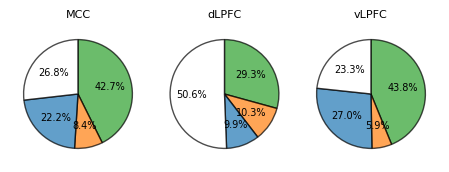

In [12]:
# plot neuron comparison
fig = plot_neuron_comparison(df_unit_significances, save_path=None, paperformat=True)

floc = os.path.join('figs', 'neuron_comparison_significant_units.svg')
fig.savefig(
    floc,
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

### Showing weights of coding

MCC - Value only: pos: 676, neg: 1071 -> proportion of negatives: 0.61
Binomial test for MCC - Value only: p-value = 0.0000
MCC - Value only: pos: 362, neg: 461 -> proportion of negatives: 0.56
Binomial test for MCC - Value only: p-value = 0.0006
dLPFC - Value only: pos: 265, neg: 406 -> proportion of negatives: 0.61
Binomial test for dLPFC - Value only: p-value = 0.0000
dLPFC - Value only: pos: 164, neg: 181 -> proportion of negatives: 0.52
Binomial test for dLPFC - Value only: p-value = 0.3890
vLPFC - Value only: pos: 87, neg: 165 -> proportion of negatives: 0.65
Binomial test for vLPFC - Value only: p-value = 0.0000
vLPFC - Value only: pos: 48, neg: 69 -> proportion of negatives: 0.59
Binomial test for vLPFC - Value only: p-value = 0.0640


/var/folders/27/vz2x5s696jv_fnk5tpw5z1gw0000gn/T/ipykernel_13956/1114347519.py:325: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


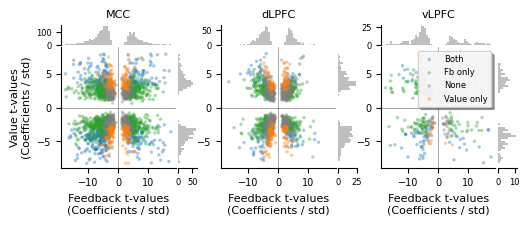

In [13]:
# plot coeffs
fig = plot_coeffs_vs_feedback_value(df_unit_significances, paper_format=True)

savedir = os.path.join('figs', 'coeffs_vs_feedback_value_significant_units.svg')
fig.savefig(
    savedir,
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

### Show on surface

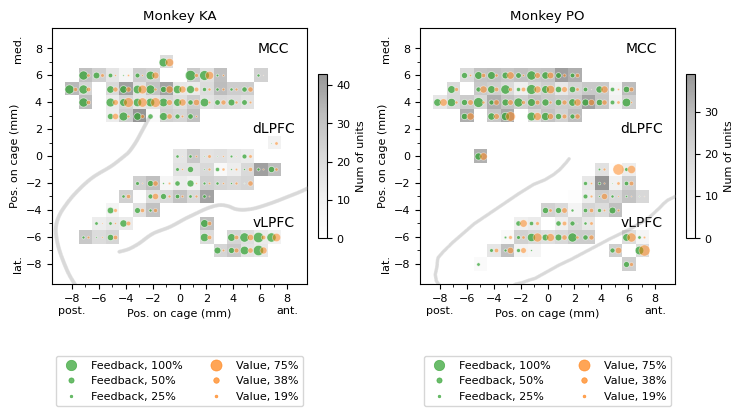

In [14]:
# plot on cortical surface
var = "n_units"
fig, axs = plot_on_cortical_grid(
    prop_units,
    column_to_show=var,
    title=None, 
    bar_title="Num of units")

# save figure

floc = os.path.join('figs', f"glm_fb_value_on_cortical_grid.svg")
fig.savefig(floc, dpi=300, bbox_inches="tight", transparent=True)